In [ ]:
import sys

sys.path.append("..")
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from numbers import Number
from qiskit.synthesis import LieTrotter
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt

 ## Try Unitary AQC 

### Try MPF for the trotter evolution (?)

### Try differently

In [ ]:
service = QiskitRuntimeService(instance="client-enablement/solutions/demo-testing")
backend = service.backend("ibm_torino")

qubit_subset = [4, 5, 6, 7, 8, 16, 17, 23, 24, 25, 26, 27]  # trying 1 loop for torino
remap = {q: i for q, i in zip(qubit_subset, range(len(qubit_subset)))}
rev_map = {val: key for key, val in remap.items()}

cm = backend.coupling_map
reduced_map = cm.reduce(qubit_subset)
edge_list = {(a, b) if a < b else (b, a) for a, b in list(reduced_map.get_edges())}
ent_dec = [(rev_map[i], rev_map[j]) for i, j in edge_list]


def Heisenberg(J, n, ent_map):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    return H.chop()


H = Heisenberg(1, 12, edge_list)


def prep_psi_0_with_checkpoints(qc: QuantumCircuit):
    qc.cx(12, 9)
    qc.cx(9, 10)
    qc.cx(10, 11)
    qc.cx(9, 8)
    qc.cx(11, 6)
    qc.cx(8, 7)
    qc.cx(7, 5)
    qc.cx(6, 4)
    qc.cx(4, 3)
    qc.cx(5, 0)
    qc.cx(3, 2)
    # make checkpoints
    qc.cx(11, 17)
    qc.cx(4, 16)
    qc.cx(2, 15)
    qc.cx(0, 14)
    qc.cx(7, 13)
    # undo entanglement on undesired qubits
    qc.cx(2, 3)
    qc.cx(4, 6)
    qc.cx(11, 10)
    qc.cx(9, 8)
    qc.cx(7, 5)
    return qc


def prep_psi_0_by_0_with_checkpoints(qc: QuantumCircuit):
    qc.cx(12, 9, ctrl_state="0")
    qc.cx(17, 11, ctrl_state="0")
    qc.cx(16, 4, ctrl_state="0")
    qc.cx(15, 2, ctrl_state="0")
    qc.cx(14, 0, ctrl_state="0")
    qc.cx(13, 7, ctrl_state="0")
    return qc

In [53]:
from qiskit.transpiler import generate_preset_pass_manager

t_steps = 8
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / 40

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * delta_t, 0, 1)
Rxyz_circ.ryy(2 * delta_t, 0, 1)
Rxyz_circ.rzz(2 * delta_t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
qc_temp = QuantumCircuit(12)
for edge in edge_list:
    qc_temp.append(Rxyz_instr, edge)
time_evol = QuantumCircuit(12).compose(qc_temp)

real_obs_H = SparsePauliOp("XXXXXX", 1) ^ H
imag_obs_H = SparsePauliOp("YXXXXX", 1) ^ H
real_obs_S = SparsePauliOp("XXXXXX", 1) ^ SparsePauliOp("I" * 12, 1)
imag_obs_S = SparsePauliOp("YXXXXX", 1) ^ SparsePauliOp("I" * 12, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(18)
        qc.h(12)
        qc = prep_psi_0_with_checkpoints(qc)
        for _ in range(n):
            qc.append(time_evol, range(12))
        qc = prep_psi_0_by_0_with_checkpoints(qc)
        for _ in range(m):
            qc.append(time_evol, range(12))
        circuits[i][j] = qc.copy()

pm = generate_preset_pass_manager(
    backend=backend, optimization_level=3, scheduling_method="alap"
)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]

In [54]:
f"Max circuit depth:{max([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"

'Max circuit depth:55'

In [55]:
f"Max number of 2q gates= {max([circs[i][j].num_nonlocal_gates() for i in range(t_steps) for j in range(t_steps)])}"

'Max number of 2q gates= 279'

### Circuit execution

In [56]:
# basis state has energy -12
from qiskit_ibm_runtime import EstimatorV2, Batch, EstimatorOptions

pub1 = [
    (
        circ,
        [
            real_obs_H.apply_layout(circ.layout),
            imag_obs_H.apply_layout(circ.layout),
            real_obs_S.apply_layout(circ.layout),
            imag_obs_S.apply_layout(circ.layout),
        ],
    )
    for circ_list in circs[0:2]
    for circ in circ_list
]
pub2 = [
    (
        circ,
        [
            real_obs_H.apply_layout(circ.layout),
            imag_obs_H.apply_layout(circ.layout),
            real_obs_S.apply_layout(circ.layout),
            imag_obs_S.apply_layout(circ.layout),
        ],
    )
    for circ_list in circs[2:4]
    for circ in circ_list
]
pub3 = [
    (
        circ,
        [
            real_obs_H.apply_layout(circ.layout),
            imag_obs_H.apply_layout(circ.layout),
            real_obs_S.apply_layout(circ.layout),
            imag_obs_S.apply_layout(circ.layout),
        ],
    )
    for circ_list in circs[4:6]
    for circ in circ_list
]
pub4 = [
    (
        circ,
        [
            real_obs_H.apply_layout(circ.layout),
            imag_obs_H.apply_layout(circ.layout),
            real_obs_S.apply_layout(circ.layout),
            imag_obs_S.apply_layout(circ.layout),
        ],
    )
    for circ_list in circs[6:8]
    for circ in circ_list
]



with Batch(backend=backend) as batch:
    estimator = EstimatorV2(mode=batch)
    estimator.options.default_shots = 50000
    estimator.options.resilience_level = 2
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    est_job_1 = estimator.run(pub1)
    est_job_2 = estimator.run(pub2)
    est_job_3 = estimator.run(pub3)
    est_job_4 = estimator.run(pub4)

In [57]:
est_job_1_results = service.job(est_job_1.job_id()).result()

est_job_2_results = service.job(est_job_2.job_id()).result()

est_job_3_results = service.job(est_job_3.job_id()).result()

est_job_4_results = service.job(est_job_4.job_id()).result()

In [58]:
idx = 0
for i in range(2):
    for j in range(t_steps):
        H_tilde[i, j] = (
            est_job_1_results[idx].data.evs[0] + 1j * est_job_1_results[idx].data.evs[1]
        )
        S_tilde[i, j] = (
            est_job_1_results[idx].data.evs[2] + 1j * est_job_1_results[idx].data.evs[3]
        )
        idx += 1

idx = 0
for i in range(2, 4):
    for j in range(t_steps):
        H_tilde[i, j] = (
            est_job_2_results[idx].data.evs[0] + 1j * est_job_2_results[idx].data.evs[1]
        )
        S_tilde[i, j] = (
            est_job_2_results[idx].data.evs[2] + 1j * est_job_2_results[idx].data.evs[3]
        )
        idx += 1

idx = 0
for i in range(4, 6):
    for j in range(t_steps):
        H_tilde[i, j] = (
            est_job_3_results[idx].data.evs[0] + 1j * est_job_3_results[idx].data.evs[1]
        )
        S_tilde[i, j] = (
            est_job_3_results[idx].data.evs[2] + 1j * est_job_3_results[idx].data.evs[3]
        )
        idx += 1

idx = 0
for i in range(6, 8):
    for j in range(t_steps):
        H_tilde[i, j] = (
            est_job_3_results[idx].data.evs[0] + 1j * est_job_3_results[idx].data.evs[1]
        )
        S_tilde[i, j] = (
            est_job_3_results[idx].data.evs[2] + 1j * est_job_3_results[idx].data.evs[3]
        )
        idx += 1

In [59]:
from sympy import Matrix
Matrix(S_tilde)

Matrix([
[      0.392803436986228 - 0.167701962246779*I,   0.00983771022802546 - 0.00318524003098812*I, 0.00590982310357203 + 0.000576295631493934*I,  1.82715994973389e-18 - 0.00248611197098718*I,  -8.73938535550972e-5 + 0.0142243153892738*I,  -0.00719124228203756 + 0.000746133717002115*I,  0.0140603459814865 - 0.000149140958066729*I,   0.00732528791420622 + 0.00193570061975238*I],
[   0.0108472465867662 + 0.00624571679865044*I,   0.0867272672942576 + 0.000223668371309127*I,  -0.00887973891411897 + 0.0201938952325254*I,   -0.00420984360040859 + 0.0045262416442019*I,   0.0053179647286035 - 0.00241475863934642*I,    0.0131635262081583 - 0.000694463983360426*I,  2.28975592472372e-17 + 0.0053283166891418*I,  0.00101673129848581 - 0.000113866378312855*I],
[  8.91384322836859e-5 - 0.00430743996026886*I,   0.00578897882503005 + 0.00383037669392949*I,   0.0117382299861214 - 0.00225222532081453*I,    0.0040957495941091 + 0.00247666045645601*I, -1.2930107385678e-17 - 0.00111138479493746*I,   0.0

In [60]:
Matrix(H_tilde)

Matrix([
[    -3.34399513502205 + 1.77078877741257*I, -0.0259638274224812 - 0.0582133811163607*I,  0.0830145980126243 + 0.0987356097114446*I,   -0.0418962277139455 + 0.10989794000945*I,      0.1123885015797 - 0.0879565353357156*I,     0.140078189459676 - 0.103874431542527*I, -0.0714628208707165 + 0.0372153669780467*I,  -0.0758362378195509 - 0.0970492147078084*I],
[  -0.189985036247741 - 0.112855506542614*I,   -0.875152185431522 + 0.148911281195704*I, -0.0151099868634502 - 0.0826602303232709*I,  -0.00322813990638961 - 0.14483762064072*I, 0.000736968979500071 - 0.0375822165464251*I,  -0.0583036985026116 - 0.0110825598117743*I, -0.0435544589963083 + 0.0530865987241166*I,    0.102258338617297 - 0.0493620134986481*I],
[7.31393710831172e-5 + 0.0182572437274228*I, 0.00125426360011988 - 0.0508386147841731*I,  -0.0879310097775249 + 0.109253287707213*I, -0.0337840376665378 + 0.0230278264613282*I,   -0.100824762436597 + 0.0552626495819371*I, -0.0684062602032018 + 0.00869145704484194*I,  0.0462416

1
2
3
3
3
4
4
4


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning:

Casting complex values to real discards the imaginary part

/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning:

Casting complex values to real discards the imaginary part



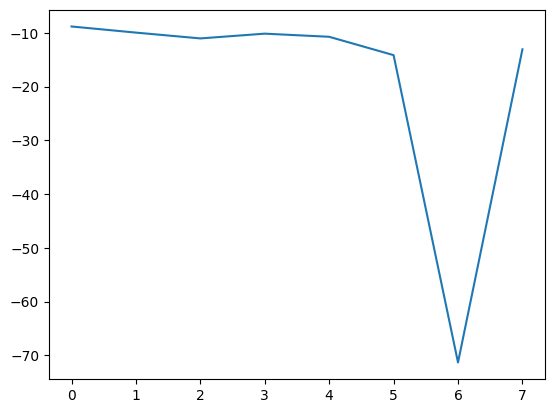

In [62]:
def truncation(threshold, S):
    eigvals, eigvecs = np.linalg.eig(S)
    idx = eigvals.argsort()[::-1]   
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:,idx]
    D = len(eigvals)
    truncated_eigvals = []
    truncated_eigvecs = []
    #make truncated matrix whose rows are eigenvectors of S with eigval above threshold
    for i in range(D):
        if eigvals[i] >= threshold:
            truncated_eigvals.append(eigvals[i])
            truncated_eigvecs.append(eigvecs[i])
    truncated_eigvals = np.array(truncated_eigvals)
    truncated_eigvecs = np.array(truncated_eigvecs).T    
    return truncated_eigvecs

def E_vs_D(H_tilde, S_tilde, threshold_slope):
    GSEs = []
    ground_states = []
    for d in range(1, len(S_tilde)+1):
        epsilon = threshold_slope*d
        H_temp = H_tilde[0:d, 0:d]
        S_temp = S_tilde[0:d, 0:d]
        V_eps = truncation(epsilon, S_temp)
        #solve GEVP
        A = V_eps.conj().T @ H_temp @ V_eps
        B = V_eps.conj().T @ S_temp @ V_eps
        print(A.shape[0])
        E, c = scipy.linalg.eig(a = A, b = B)
        idx = E.argsort()[::-1]   
        eigvals = E[idx]
        eigvecs = c[:,idx]
        GSEs.append(eigvals[-1])
        ground_states.append(eigvecs[:,-1])
    return GSEs, ground_states, V_eps
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-8)
plt.plot(GSEs)

# Run on simulator for comparison

In [63]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.primitives import StatevectorEstimator

t_steps = 8
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / 40

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * delta_t, 0, 1)
Rxyz_circ.ryy(2 * delta_t, 0, 1)
Rxyz_circ.rzz(2 * delta_t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
qc_temp = QuantumCircuit(12)
for edge in edge_list:
    qc_temp.append(Rxyz_instr, edge)
time_evol = QuantumCircuit(12).compose(qc_temp)

real_obs_H = SparsePauliOp("XXXXXX", 1) ^ H
imag_obs_H = SparsePauliOp("YXXXXX", 1) ^ H
real_obs_S = SparsePauliOp("XXXXXX", 1) ^ SparsePauliOp("I" * 12, 1)
imag_obs_S = SparsePauliOp("YXXXXX", 1) ^ SparsePauliOp("I" * 12, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(18)
        qc.h(12)
        qc = prep_psi_0_with_checkpoints(qc)
        for t in range(n):
            qc.append(time_evol, range(12))
        qc = prep_psi_0_by_0_with_checkpoints(qc)
        for t in range(m):
            qc.append(time_evol, range(12))
        circuits[i][j] = qc.copy()

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])


sv = StatevectorEstimator()
sv_job = sv.run(
    [
        (circs[i][j], [real_obs_H, imag_obs_H, real_obs_S, imag_obs_S])
        for i in range(t_steps)
        for j in range(t_steps)
    ]
)

sv_res = sv_job.result()

In [ ]:
idx = 0
for i in range(t_steps):
    for j in range(t_steps):
        H_tilde[i, j] = sv_res[idx].data.evs[0] + 1j * sv_res[idx].data.evs[1]
        S_tilde[i, j] = sv_res[idx].data.evs[2] + 1j * sv_res[idx].data.evs[3]
        idx += 1

Matrix(S_tilde)

Matrix([
[                                       1.0,   -0.266330858414137 + 0.819682098382944*I,   -0.40786385281419 - 0.367177106925886*I,  0.259540301515939 - 0.0374537861912528*I, -0.102857547861403 + 0.0552716285493855*I, 0.0734454813427768 - 0.0343579292596322*I, -0.0781544545967537 + 0.0456066602541027*I,  0.0626158868497555 - 0.0908612919511311*I],
[  -0.266330858414137 + 0.819682098382944*I,                          0.999999999999999,  -0.266330858414137 + 0.819682098382943*I,   -0.40786385281419 - 0.367177106925886*I,  0.259540301515939 - 0.0374537861912528*I, -0.102857547861403 + 0.0552716285493855*I,  0.0734454813427767 - 0.0343579292596323*I, -0.0781544545967536 + 0.0456066602541027*I],
[   -0.40786385281419 - 0.367177106925886*I,   -0.266330858414137 + 0.819682098382943*I,                         0.999999999999997,  -0.266330858414136 + 0.819682098382942*I,   -0.40786385281419 - 0.367177106925885*I,  0.259540301515939 - 0.0374537861912528*I,  -0.102857547861403 + 0.055271

In [66]:
Matrix(H_tilde)

Matrix([
[                                  -12.0,      6.44605961909949 - 9.32576049822317*I,      3.23814766534539 + 8.53998277470163*I,   -5.55275749948514 - 2.01013285738879*I,     3.26664401751588 - 0.658908898957747*I,    -2.13163510877534 + 0.921184712768624*I,     1.78799937371354 - 1.34561488854094*I,     -1.18759776689029 + 1.97169623691681*I],
[  6.44605961909949 - 9.32576049822317*I, -11.9630008761234 - 2.15108106536178e-16*I,      6.43232414892667 - 9.26373005417662*I,    3.18151686989539 + 8.50887091677196*I,     -5.51510005337971 - 2.03663013912933*I,      3.26174169118044 - 0.63259667936872*I,   -2.13580104655897 + 0.903669799934011*I,      1.79794646139395 - 1.33288744389525*I],
[  3.23814766534539 + 8.53998277470163*I,      6.43232414892667 - 9.26373005417662*I, -11.8678442588519 + 5.10306489287175e-16*I,      6.4098531748291 - 9.1662313466914*I,      3.11522890002207 + 8.46995836618559*I,       -5.477416446078 - 2.05908768202122*I,    3.25412814824539 - 0.61279529591

1
2
3
4
5
6
7
8


/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning:

Casting complex values to real discards the imaginary part

/Users/ibrahimshehzad/uds/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning:

Casting complex values to real discards the imaginary part



Text(0, 0.5, 'Ground state energy')

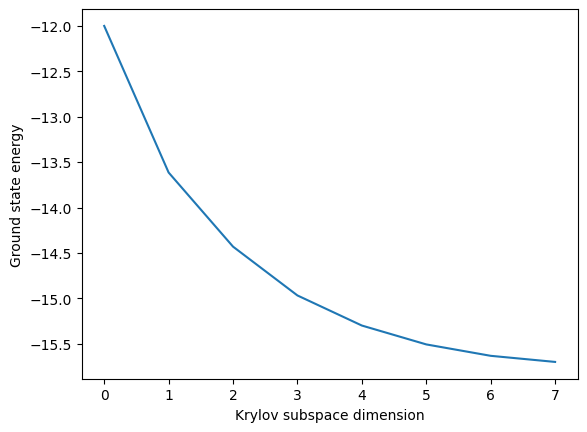

In [67]:
GSEs, vecs, V_eps = E_vs_D(H_tilde, S_tilde, 1e-8)
plt.plot(GSEs)  # Ground-state energies
# V_eps is the truncation matrix, removes smallest singular values from S-tilde.
plt.xlabel("Krylov subspace dimension")
plt.ylabel("Ground state energy")